In [1]:
import math
import sys
import os
import random
from datetime import datetime
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', None)

%load_ext autoreload
%autoreload 2

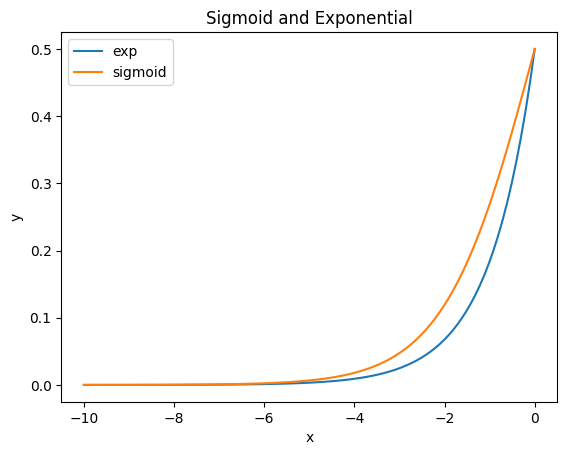

In [14]:
x = np.linspace(-10, 0, 100)
y1 = np.exp(x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

y2 = sigmoid(x)

plt.plot(x, y1 * 0.5, label='exp')
plt.plot(x, y2, label='sigmoid')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sigmoid and Exponential")
plt.legend();

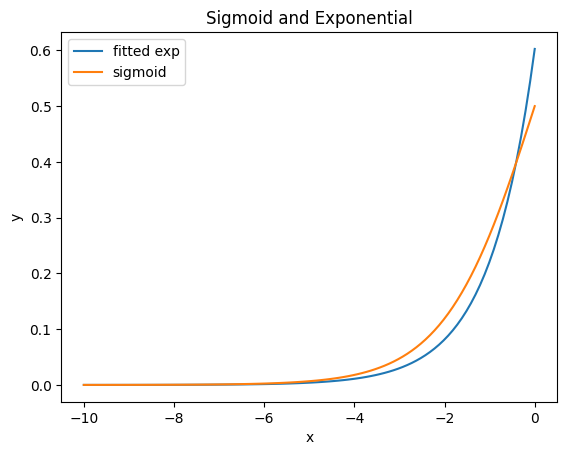

In [18]:
from scipy.optimize import curve_fit

def exp_model(x, C):
    return C * np.exp(x)

parameters, parameter_covariance = curve_fit(exp_model, x, y2)
parameters, parameter_covariance

y1 = exp_model(x, *parameters)

plt.plot(x, y1, label='fitted exp')
plt.plot(x, y2, label='sigmoid')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sigmoid and Exponential")
plt.legend();

In [ ]:
np.random.seed(42)

shift: -0.8305072533139075, scale: 1.1329276578251974
[0.31349819 0.96392532]


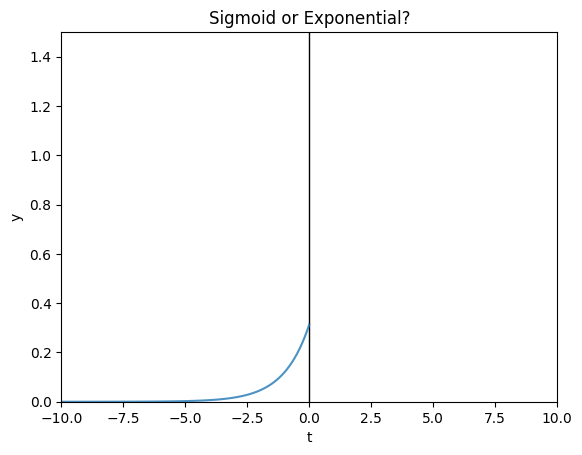

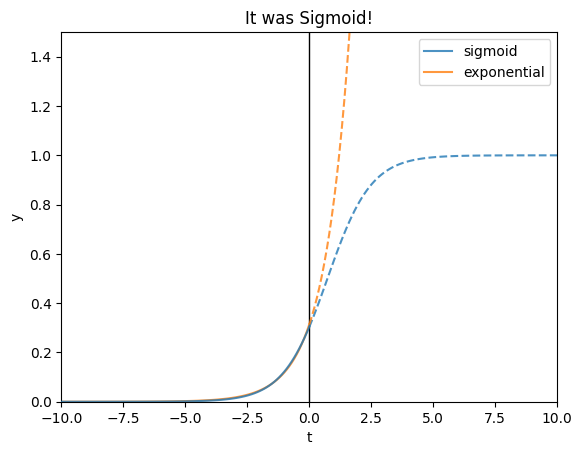

In [136]:
from scipy.stats import loguniform
shift = np.random.uniform(-1, 0)
scale = loguniform.rvs(1/3, 3)
which = 'exponential' if np.random.random() < 0.5 else 'sigmoid'
print(f"shift: {shift}, scale: {scale}")

blue = '#1f77b4'
orange = '#ff7f0e'
alpha = 0.8

def exp_model(x, C, b):
    return C * np.exp(b * x)

x_left = np.linspace(-10, 0, 100)
y1_left = sigmoid(x_left * scale + shift)

parameters, parameter_covariance = curve_fit(exp_model, x_left, y1_left, p0=[1, 1])
parameters, parameter_covariance
y2_left = exp_model(x_left, *parameters)
print(parameters)

# Question
plt.axvline(0, color='black', lw=1)
plt.xlim(-10, 10)
plt.xlabel("t")
plt.ylabel("y")
plt.ylim(0, 1.5)
if which == 'exponential':
    plt.plot(x_left, y1_left, alpha=alpha, label='exponential')
elif which == 'sigmoid':
    plt.plot(x_left, y2_left, alpha=alpha, label='sigmoid')
plt.title("Sigmoid or Exponential?")
plt.show()

# Answer
plt.axvline(0, color='black', lw=1)
plt.xlabel("t")
plt.ylabel("y")
plt.xlim(-10, 10)
plt.ylim(0, 1.5)
plt.title(f"It was {which.title()}!")

x_right = np.linspace(0, 10, 100)
y1_right = sigmoid(x_right * scale + shift)
y2_right = exp_model(x_right, *parameters)

exponential_color = blue if which == 'exponential' else orange
sigmoid_color = blue if which == 'sigmoid' else orange
zorder = +10 if which == 'sigmoid' else -10

plt.plot(x_left, y1_left, color=sigmoid_color, alpha=alpha, label='sigmoid', zorder=zorder)
plt.plot(x_left, y2_left, color=exponential_color, alpha=alpha, label='exponential')
plt.plot(x_right, y1_right, color=sigmoid_color, alpha=alpha, linestyle='dashed')
plt.plot(x_right, y2_right, color=exponential_color, alpha=alpha, linestyle='dashed')
plt.legend();
None

In [169]:
import numpy as np
from scipy.stats import loguniform
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from pptx import Presentation
from pptx.util import Inches
import io

np.random.seed(37)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def exp_model(x, C, b):
    return C * np.exp(b * x)

def create_plot(shift, scale, which, question):
    blue = '#1f77b4'
    orange = '#ff7f0e'

    x_left = np.linspace(-10, 0, 100)
    y1_left = sigmoid(x_left * scale + shift)
    parameters, _ = curve_fit(exp_model, x_left, y1_left, p0=[1, 1])
    y2_left = exp_model(x_left, *parameters)

    x_right = np.linspace(0, 10, 100)
    y1_right = sigmoid(x_right * scale + shift)
    y2_right = exp_model(x_right, *parameters)

    fig, ax = plt.subplots()
    if question:
        ax.axvline(0, color='black', lw=1)
        ax.set(xlim=(-10, 10), ylim=(0, 1.5))
        ax.set_xlabel("t")
        ax.set_ylabel("y")
        ax.set_title("Sigmoid or Exponential?")
        if which == 'sigmoid':
            ax.plot(x_left, y1_left, color=blue, alpha=0.8)
        elif which == 'exponential':
            ax.plot(x_left, y2_left, color=blue, alpha=0.8)
    else:
        sigmoid_color = blue if which == 'sigmoid' else orange
        exponential_color = blue if which == 'exponential' else orange
        ax.axvline(0, color='black', lw=1)
        ax.set(xlim=(-10, 10), ylim=(0, 1.5))
        ax.set_xlabel("t")
        ax.set_ylabel("y")
        ax.set_title(f"It was {which.title()}!")
        zorder = +10 if which == 'sigmoid' else -10
        ax.plot(x_left, y1_left, color=sigmoid_color, alpha=0.8, label='sigmoid', zorder=zorder)
        ax.plot(x_left, y2_left, color=exponential_color, alpha=0.8, label='exponential')
        ax.plot(x_right, y1_right, color=sigmoid_color, alpha=0.8, linestyle='dashed')
        ax.plot(x_right, y2_right, color=exponential_color, alpha=0.8, linestyle='dashed')
        ax.legend()
    buf = io.BytesIO()
    plt.savefig(buf, format='png')
    plt.close(fig)
    buf.seek(0)
    return buf

# Create a presentation
prs = Presentation()
blank_layout = prs.slide_layouts[6]

for _ in range(10):
    # Generate random problem
    shift = np.random.uniform(-1, 0)
    scale = loguniform.rvs(1/3, 3)
    which = 'exponential' if np.random.random() < 0.5 else 'sigmoid'
    
    # Question slide
    slide = prs.slides.add_slide(blank_layout)
    pic = slide.shapes.add_picture(create_plot(shift, scale, which, question=True), Inches(1), Inches(1), width=Inches(8))

    # Answer slide
    slide = prs.slides.add_slide(blank_layout)
    pic = slide.shapes.add_picture(create_plot(shift, scale, which, question=False), Inches(1), Inches(1), width=Inches(8))

prs.save('presentation.pptx')


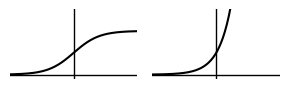

In [161]:
# Create plot for the modified sigmoid and exponential functions with specific style settings

# Redefine functions for clarity
def sigmoid(x, k, s):
    return 1 / (1 + np.exp(-k * (x + s)))

def exponential(x, C, b):
    return C * np.exp(b * x)

# Generate x values
x = np.linspace(-10, 10, 400)

# Compute y values for each function
y_sigmoid = sigmoid(x, 1, 0)
y_exponential = exponential(x, 0.5, 1)

# Create the figure and the axes for two subplots
fig, axs = plt.subplots(1, 2, figsize=(3, 1))

# Plotting the sigmoid function
axs[0].plot(x, y_sigmoid, color='black', linewidth=1.5)
axs[0].set_xlim([-5, 5])
axs[0].set_ylim([-0.1, 1.5])
axs[0].axvline(0, color='black', linewidth=1)
axs[0].axhline(0, color='black', linewidth=1)

# Plotting the exponential function
axs[1].plot(x, y_exponential, color='black', linewidth=1.5)
axs[1].set_xlim([-5, 5])
axs[1].set_ylim([-0.1, 1.5])
axs[1].axvline(0, color='black', linewidth=1)
axs[1].axhline(0, color='black', linewidth=1)

# Remove grids and set tight layout
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(labelbottom=False, labelleft=False)
    ax.tick_params(bottom=False, left=False)

plt.tight_layout()
plt.show()
